In [1]:
# ============================================================
# CUSTOMER CHURN ANALYTICS & RETENTION PREDICTION PROJECT
# ============================================================

# Project Objective:
# The objective of this project is to analyze customer behavior
# and build machine learning models to predict customer churn.
# The project also includes business insights and dashboarding
# using Power BI for strategic decision-making.

In [3]:
# ============================================================
# IMPORTING REQUIRED LIBRARIES
# ============================================================

# pandas -> used for data manipulation and analysis
# numpy -> used for numerical operations
# matplotlib -> used for data visualization
# seaborn -> used for advanced statistical visualizations


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================================
# LOADING DATASET
# ============================================================

# Read telecom customer churn dataset into a pandas dataframe

df = pd.read_csv(r"C:\Users\asmit\OneDrive\Desktop\Customer_Churn_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [7]:
# Display first 5 rows of dataset
# Helps understand column structure and sample records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Display dataset information such as:
# - total entries
# - column names
# - data types
# - missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Check total rows and columns in dataset
df.shape

(7043, 21)

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
# Check missing/null values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
# ============================================================
# DATA CLEANING
# ============================================================

# Convert TotalCharges column from object/string to numeric format
# Invalid values are converted to NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [21]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [23]:
# Replace missing values in TotalCharges using median value
# Median is preferred because it handles outliers effectively
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [27]:
# Remove customerID column because it is only a unique identifier
# and does not contribute to churn prediction
df.drop('customerID', axis=1, inplace=True , errors='ignore')

In [29]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


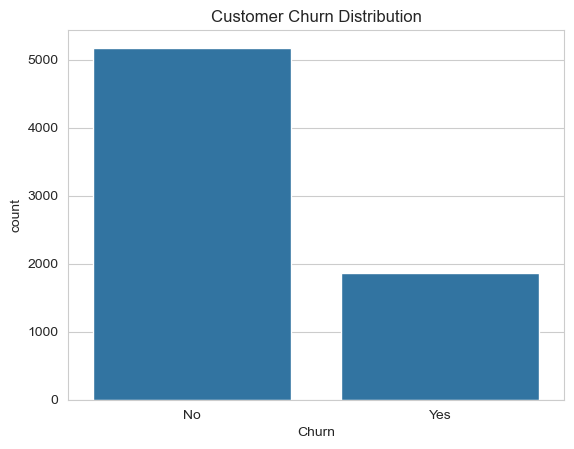

In [31]:
# Visualize overall churn distribution
sns.set_style("whitegrid")
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

# Interpretation:
# The chart shows that the majority of customers were retained,
# while a smaller proportion of customers churned.
# This indicates that customer retention is relatively strong,
# but there is still a significant number of customers leaving the company.
# The dataset is slightly imbalanced because retained customers
# are much higher than churned customers.

In [33]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

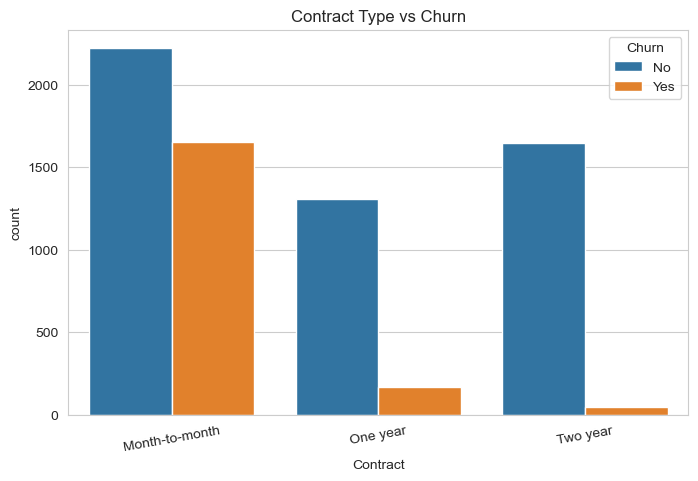

In [39]:
# Analyze churn behavior across different contract types
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)

plt.show()

# Interpretation:
# Customers with month-to-month contracts exhibited the highest churn rate,
# indicating that short-term customers are more likely to leave the company.
# In contrast, customers with one-year and two-year contracts showed
# significantly lower churn behavior, suggesting that long-term contracts
# improve customer retention and loyalty.

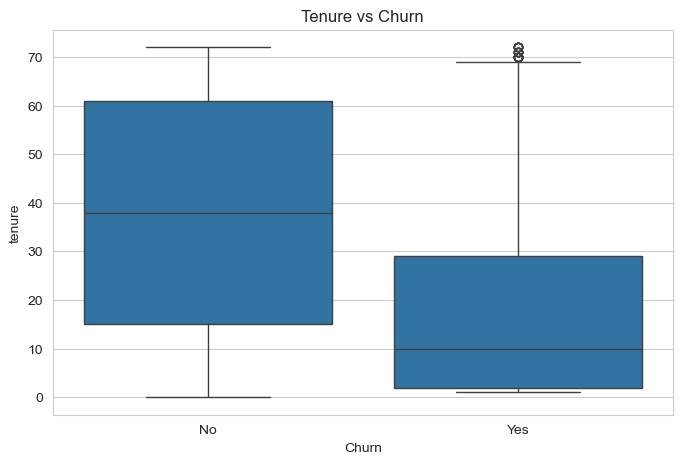

In [41]:
# Analyze relationship between customer tenure and churn

plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

# Interpretation:
# Customers with lower tenure showed higher churn behavior,
# indicating that newer customers are more likely to leave the company.
# Customers who stayed longer with the company demonstrated
# significantly better retention and loyalty.
# This suggests that customer retention strategies should focus
# more on early-stage customers.

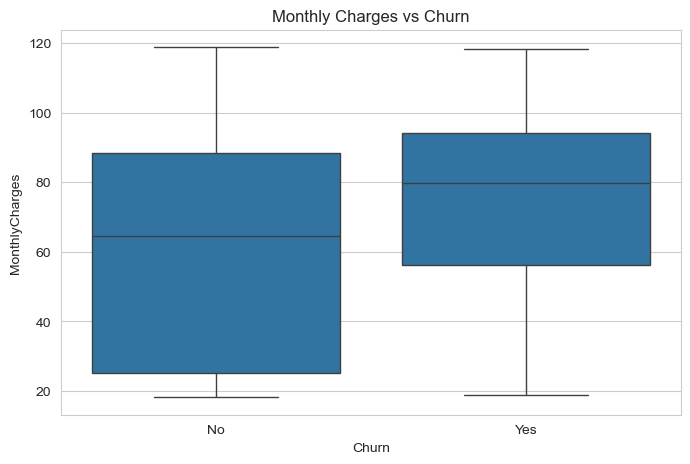

In [43]:
# Analyze effect of monthly charges on churn behavior

plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

# Interpretation:
# Customers with higher monthly charges exhibited relatively higher churn behavior,
# indicating that pricing may influence customer retention.
# Customers paying lower monthly charges were more likely to stay with the company.
# This suggests that high pricing or perceived value concerns
# may contribute to customer churn.

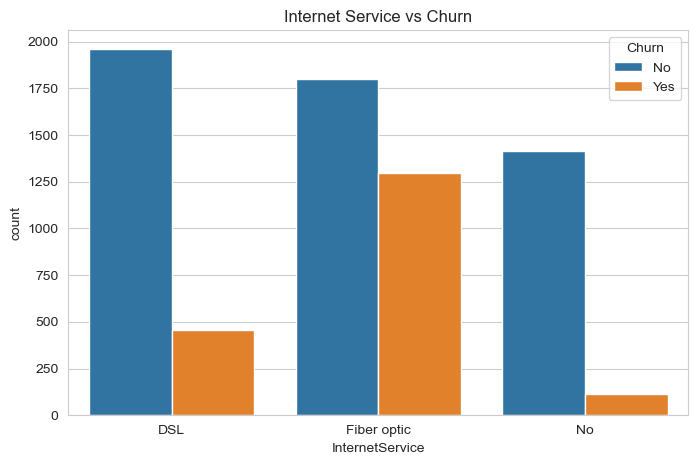

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Churn")

plt.show()

# Interpretation:
# Customers using fiber optic internet service showed significantly higher churn behavior
# compared to DSL and customers without internet service.
# In contrast, DSL users and customers with no internet service
# demonstrated relatively better retention rates.
# This suggests that factors such as pricing, service quality,
# or customer expectations may influence churn among fiber optic users.

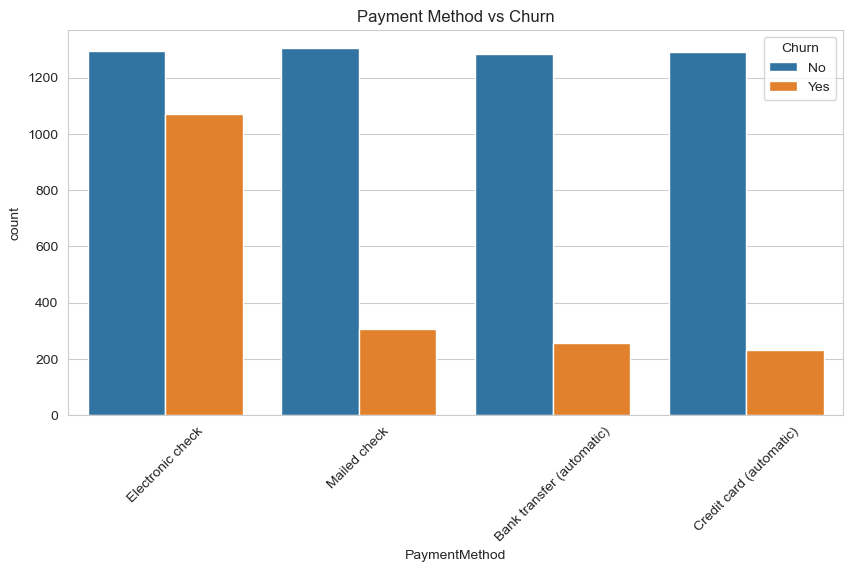

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

# Interpretation:
# Customers using electronic check payment methods showed the highest churn behavior
# compared to other payment methods.
# In contrast, customers using automatic payment methods such as
# bank transfer and credit card demonstrated better retention rates.
# This suggests that automated payment methods may improve
# customer convenience and long-term retention.

In [49]:
# ============================================================
# TARGET VARIABLE ENCODING
# ============================================================

# Convert churn labels into numerical format:
# Yes -> 1 (Customer Churned)
# No -> 0 (Customer Retained)

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

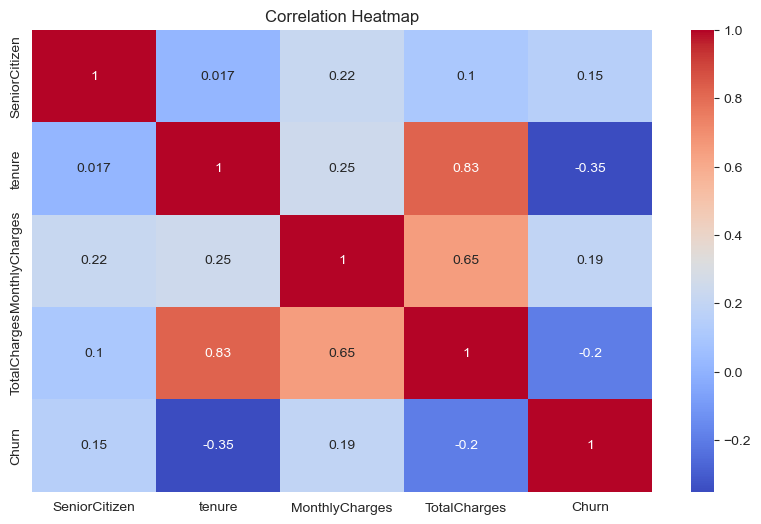

In [51]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Interpretation:
# The correlation heatmap shows the relationship between numerical variables.
# Tenure has a moderate negative correlation with churn,
# indicating that customers with longer tenure are less likely to leave the company.
# MonthlyCharges shows a slight positive relationship with churn,
# suggesting that higher monthly charges may contribute to customer churn.
# TotalCharges has a negative relationship with churn because
# long-term retained customers generally accumulate higher total charges over time.
# Overall, tenure appears to be one of the most influential factors affecting churn behavior.

In [54]:
df['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [56]:
# ============================================================
# FEATURE ENCODING
# ============================================================

# Convert categorical variables into numerical format
# using one-hot encoding for machine learning models

df = pd.get_dummies(df, drop_first=True)

In [58]:
# ============================================================
# DEFINING FEATURES AND TARGET VARIABLE
# ============================================================

# X -> independent variables/features
# y -> target variable (Churn)

X = df.drop('Churn', axis=1)
y = df['Churn']

In [60]:
# ============================================================
# SPLITTING DATA INTO TRAINING AND TESTING SETS
# ============================================================

# 80% data -> training
# 20% data -> testing

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [96]:
y_pred = lr.predict(X_test)

In [97]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [100]:
print(confusion_matrix(y_test, y_pred))

[[934 102]
 [150 223]]


In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [104]:
accuracy_score(y_test, y_pred)

0.8211497515968772

In [ ]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

# Random Forest is an ensemble learning algorithm
# that combines multiple decision trees for prediction

In [106]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [108]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [109]:
rf_pred = rf.predict(X_test)

In [112]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
accuracy_score(y_test, rf_pred)

'''“Although Random Forest is a powerful ensemble model, Logistic Regression performed better for this dataset in terms of churn detection recall and overall accuracy. This indicates the dataset may have relatively linear decision boundaries.”'''

[[941  95]
 [202 171]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



'“Although Random Forest is a powerful ensemble model, Logistic Regression performed better for this dataset in terms of churn detection recall and overall accuracy. This indicates the dataset may have relatively linear decision boundaries.”'

In [114]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [116]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [118]:
importance.head(10)

,Feature,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


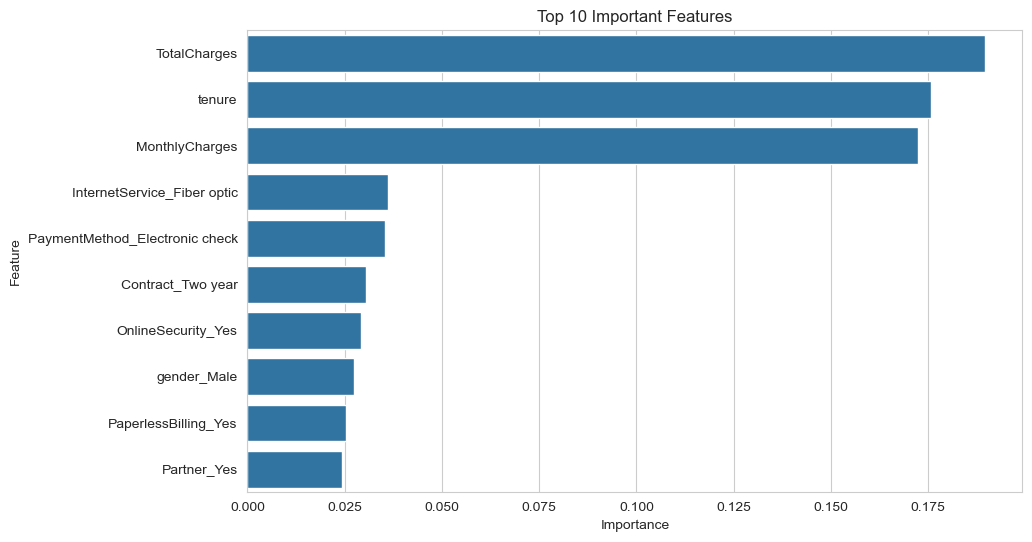

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# Business Recommendations :
# ntroduce retention campaigns for short-tenure customers.
# Provide pricing optimization for high monthly charge customers.
# Improve customer engagement for high-risk segments.
# Use predictive monitoring to identify churn-prone customers proactively.